# Notebook 2 - Working with small molecules

In this notebook, you will learn how to work with small molecules in the computer. You will learn about the different formats and how to interconvert between them.

## Prepare yourself:

It is highly recommended that you prepare yourselves by first having a look at this movie:

- <a href="https://www.youtube.com/watch?v=w9SV2mNSBMk" target="_blank">String-based representations of molecules: SMILES, SMARTS and SELFIES</a> [YouTube - 15'00"]

Then you should have a good read of this paper:

- <a href="assets/pdf/Review_of_molecular_representation_in_the_age_of_machine_learning.pdf" download>A review of molecular representations in the age of machine learning</a> [pdf]

## Course manuals:

- <a href="assets/pdf/2-Representing_molecules_in_the_computer.pdf" download>Chapter 2: Representing molecules in the computer</a> [pdf]
- <a href="assets/pdf/3-Chemical_informatics_with_RDKit.pdf" download>Chapter 3: Chemical informatics with RDKit</a> [pdf]

## What you will learn

In notebook 1 you looked at the target. This notebook is about the other half of the problem: the
small molecules. Before you can screen, cluster or model anything, you have to be able to put a
molecule into the computer, and the way you do that determines what you can afterwards ask of it.
A molecule written as a line of text can be searched and compared in an instant, but it has no
shape; a molecule with coordinates has a shape, but one shape out of many possible ones.

At the end of this notebook you should be able to:

1. explain what SMILES, SDF and MOL2 each store, and choose the right one for a given task;
2. convert between these representations with RDKit, and detect a molecule that failed to parse;
3. treat a molecule as a graph: walk over its atoms and bonds, find its neighbours and its rings;
4. explain the difference between SMILES and InChI, and why only one of the two is unique;
5. attach properties to a molecule and write them to an SD file;
6. generate three-dimensional conformations of a molecule, and say why one conformation is usually
   not enough;
7. search for a substructure with SMARTS;
8. read a whole file of molecules and display them as a grid.

## Planning (approximately 2 hours)

| Section | Content | Time |
|---|---|---|
| 1 | SMILES, SDF and MOL2: how a molecule is written down | 15 min |
| 2 | RDKit: a molecule as a graph of atoms, bonds and rings | 30 min |
| 3 | Reading and writing: SMILES, InChI, MOL blocks, properties and conformations | 30 min |
| 4 | Substructure searching with SMARTS | 20 min |
| 5 | Working with many molecules at once | 15 min |
| 6 | Exercises | 10 min |

As in the previous notebook: predict what a cell will do before you run it. Most cells here are
three lines long, which makes that a cheap habit to acquire and a very effective one.

## 1. Working with small molecules in the computer 

Small molecules are stored in computers using standardized text-based formats that describe their chemical structure in a way that can be interpreted by software. Depending on the level of detail required, different formats are used. Three of the most common are SMILES, SDF, and MOL2. These formats differ mainly in how much structural and chemical information they encode. SMILES is a compact, line notation that captures molecular connectivity in a single string. SDF (Structure Data File) provides a more complete description, including atom coordinates and the possibility to store multiple molecules with associated properties. MOL2 goes even further by incorporating detailed atom types, charges, and substructure information, making it especially useful in molecular modeling and docking.

The simplest of these formats is SMILES (Simplified Molecular Input Line Entry System). It represents a molecule as a linear string of characters that encodes how atoms are connected. For example, methane is simply written as ```C```, while ethanol becomes ```CO```, indicating a chain of two carbons followed by an oxygen. More complex features such as branching are represented using parentheses: isopropanol is written as ```CC(C)O```, meaning that a methyl group branches off the second carbon. Double bonds are indicated with symbols like ```=```, so acetone is written as ```CC(=O)C```. Rings are handled using matching numbers that indicate where a ring closes; cyclohexane is ```C1CCCCC1```, and aromatic benzene is written as ```c1ccccc1```, where lowercase letters denote aromatic atoms. This notation is extremely compact and widely used in databases and cheminformatics workflows, although it does not inherently include three-dimensional information.

A more detailed representation is provided by the SDF format, which is based on the so-called mol-block. In contrast to SMILES, SDF explicitly lists atoms with their coordinates and defines bonds between them. A typical mol-block begins with a short header containing the molecule name and program information, followed by a counts line that specifies the number of atoms and bonds. The next section lists all atoms with their x, y, and z coordinates and element types, and this is followed by a bond table indicating which atoms are connected and the type of bond (single, double, etc.). The block ends with the line M  END. For example, a simplified mol-block might look like:

```
Example molecule
  CDK     04262026

  6  5  0  0  0  0            999 V2000
    1.2090   -0.0000    0.0000 C
    0.0000    0.0000    0.0000 C
   -0.6050    1.0460    0.0000 O
   -0.6050   -1.0460    0.0000 O
    1.8140    1.0460    0.0000 H
    1.8140   -1.0460    0.0000 H
  1  2  1
  2  3  2
  2  4  1
  1  5  1
  1  6  1
M  END
```

In an SDF file, multiple such mol-blocks can be stored sequentially, separated by ```$$$$```, and additional metadata (such as calculated properties or identifiers) can be included between structures. This makes SDF particularly useful for compound libraries and screening datasets.

Finally, the MOL2 format provides an even richer description of small molecules and is widely used in computational chemistry applications such as docking and molecular dynamics. A MOL2 file is organized into clearly labeled sections, starting with ```@<TRIPOS>MOLECULE```, followed by sections for atoms and bonds. In the atom section, each atom is listed with coordinates, an assigned atom type (reflecting its chemical environment), and often a partial charge. The bond section defines how atoms are connected and the bond order. A minimal example looks like:

```
@<TRIPOS>MOLECULE
Example_molecule
6 5 1 0 0
SMALL
NO_CHARGES

@<TRIPOS>ATOM
1 C1   1.2090  -0.0000   0.0000  C.3  1 MOL1  0.000
2 C2   0.0000   0.0000   0.0000  C.2  1 MOL1  0.000
3 O1  -0.6050   1.0460   0.0000  O.2  1 MOL1 -0.500
4 O2  -0.6050  -1.0460   0.0000  O.3  1 MOL1 -0.500

@<TRIPOS>BOND
1 1 2 1
2 2 3 2
3 2 4 1
```

Compared to SDF, MOL2 explicitly encodes chemically meaningful atom types and charges, which are essential for many modeling methods. In summary, SMILES offers a compact and efficient way to describe molecular connectivity, SDF provides a complete structural representation with coordinates and metadata, and MOL2 adds chemically rich detail required for advanced computational applications.

**Question 1.** Three representations, three different jobs. Which of the three can store the
*three-dimensional* coordinates of a molecule? Which one would you use to store a million compounds
from a vendor catalogue as compactly as possible? And which one would you need in notebook 5, where
a molecule has to be matched against a three-dimensional pharmacophore?

## 2. Using RDKit to work with small molecules

RDKit is an open-source cheminformatics library widely used to represent, manipulate, and analyze small molecules in computational chemistry and drug discovery. It provides a flexible Python interface that allows researchers to work with molecular structures programmatically, making it a central tool in workflows ranging from data curation to virtual screening and machine learning.

At its core, RDKit represents molecules as graphs, where atoms are nodes and bonds are edges. This abstraction allows it to interpret common chemical formats such as SMILES, SDF, and MOL2, converting them into internal molecular objects that can be queried and modified. For example, a SMILES string can be converted into an RDKit molecule object, which can then be used to compute properties, generate 2D or 3D coordinates, or perform substructure searches.

In [1]:
!pip install rdkit mols2grid requests

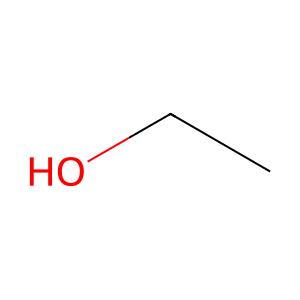

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdDepictor
IPythonConsole.ipython_useSVG = True
rdDepictor.SetPreferCoordGen(True)

# Library to display molecules in a grid
import mols2grid

# Library to download files
import requests

# Files that are generated by this notebook are written to the "scratch" folder,
# which is not tracked by git
import os
os.makedirs("scratch", exist_ok=True)

mol = Chem.MolFromSmiles("CCO")
Draw.MolToImage(mol)

A typical workflow begins with reading molecules:


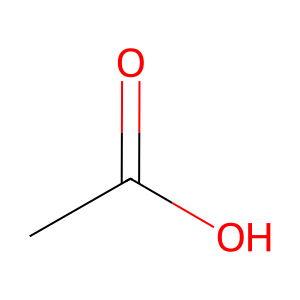

In [3]:
mol = Chem.MolFromSmiles("CC(=O)O")  # acetic acid
Draw.MolToImage(mol)

Once loaded, RDKit provides a wide range of functionality. It can calculate molecular descriptors such as molecular weight, logP, or topological polar surface area, which are important in medicinal chemistry:


In [4]:
from rdkit.Chem import Descriptors

mw = Descriptors.MolWt(mol)
logp = Descriptors.MolLogP(mol)
print(mw, logp)

60.05200000000001 0.09089999999999993


### 2.1 Displaying a chemical structure

Create a molecule (benzene) from a SMILES string and put the molecule into a variable called **mol**:

In [5]:
mol = Chem.MolFromSmiles("c1ccccc1")

We can display the value of a variable in a Jupyter notebook by typing the variable name and clicking shift-return:

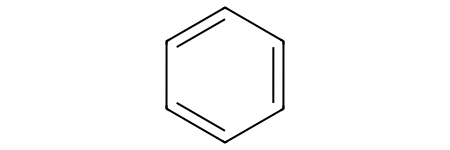

In [6]:
mol

Get some information about this molecule:

In [7]:
print("number of atoms:", mol.GetNumAtoms())
nBonds = mol.GetNumBonds()
print("number of bonds:", nBonds)

number of atoms: 6
number of bonds: 6


The **mol** variable is not readable by humans (only by RDKit), but the molecule can be converted back to a SMILES:

In [8]:
print(Chem.MolToSmiles(mol))

c1ccccc1


Invalid SMILES can be captured by testing if the molecule is not **None**:

RDKit does not raise an exception on a bad SMILES: it returns `None` and writes a message to the
log. That is deliberate - when you read a file of 100,000 compounds you do not want the whole job
to stop at the first typo - but it does mean that **you** have to check. The
`if mol is None: continue` idiom in the cell after this one is used in every single notebook that
follows.

**Question 2.** Run the cell and read the RDKit message for the second SMILES. In your own words:
what is wrong with `c`, and why is a lower-case `c` not simply "a carbon atom"?

In [9]:
for smiles in ["CCCC", "c"]:
  print("Smiles:", smiles)
  mol = Chem.MolFromSmiles(smiles)
  print(mol)
  print(mol is None)
  print("")

Smiles: CCCC
False

Smiles: c
None
True



[13:55:12] non-ring atom 0 marked aromatic


Hydrogen atoms are by default considered to be implicitly present, by not explicit. The **AllChem.AddHs()** and **AllChem.RemoveHs()** functions can be used to make the hydrogens explicit or implicit:

Hydrogens are **implicit** by default: RDKit knows from the valence of each atom how many
hydrogens must be there, without storing them as separate atoms. That keeps molecules small and
comparisons fast.

**Question 3.** Methane has one atom in RDKit's eyes and five after `AddHs()`. Later in this
notebook you will generate a 3D conformation, and in notebooks 4 and 5 you will do the same for
tens of thousands of molecules - always with `AddHs()` first. Why can a sensible three-dimensional
geometry not be produced while the hydrogens are still implicit?

In [9]:
from rdkit.Chem import AllChem
mol = Chem.MolFromSmiles("C")
print("number of atoms:", mol.GetNumAtoms())
print("number of bonds:", mol.GetNumBonds())
print("")
mol = AllChem.AddHs(mol)
print("number of atoms:", mol.GetNumAtoms())
print("number of bonds:", mol.GetNumBonds())
print("")
mol = AllChem.RemoveHs(mol)
print("number of atoms:", mol.GetNumAtoms())
print("number of bonds:", mol.GetNumBonds())

number of atoms: 1
number of bonds: 0

number of atoms: 5
number of bonds: 4

number of atoms: 1
number of bonds: 0


The SMILES representations for most marketed drugs are available from the Wikipedia page for the corresponding drug. For instance, we can get the SMILES for the oncology drug Imatinib (aka Gleevec) from [Wikipedia](https://en.wikipedia.org/wiki/Imatinib). With this SMILES string in hand, we can generate an RDKit molecule:

In [10]:
glvc = Chem.MolFromSmiles("Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C")

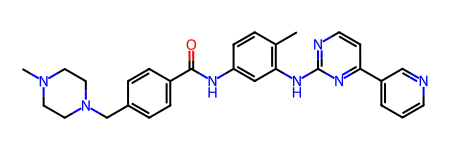

In [11]:
glvc

### 2.2 Looping over atoms and bonds

RDKit represents a molecule the way a chemist draws it: as a **graph**, in which the atoms are the
nodes and the bonds are the edges. Everything in the next few cells follows from that single idea -
you can walk over the atoms, ask each atom for its neighbours, and walk over the bonds. Each atom
carries its element, its charge, its valence and its position in the molecule.

In [13]:
mol = Chem.MolFromSmiles('C1OC1')
for atom in mol.GetAtoms():
  print(atom.GetAtomicNum(), atom.GetIdx(), atom.GetSymbol(), atom.GetValence(Chem.ValenceType.EXPLICIT))

6 0 C 2
8 1 O 2
6 2 C 2


### 2.3 Atom indices

Every atom has an **index**, a number from 0 to `GetNumAtoms() - 1`, which is its address inside
this particular molecule. Substructure searches, conformer coordinates and pharmacophore features
all refer to atoms by index, so it pays to be comfortable with them. Note that the index is a
property of the molecule object, not of the chemistry: the same compound read from a different
SMILES may number its atoms differently.

In [14]:
for i in range(0, mol.GetNumAtoms()):
  print(i, mol.GetAtomWithIdx(i).GetSymbol())

0 C
1 O
2 C


### 2.4 Atom neighbours

Asking an atom for its neighbours is how you walk through a structure. `GetNeighbors()` hands back
atom objects rather than indices - which is why the cell below prints something unreadable first and
then the indices one by one.

In [15]:
for atom in mol.GetAtoms():
  neighbors = atom.GetNeighbors()
  print(neighbors)
  print(atom.GetIdx(), end = ": ")
  for neighbor in neighbors: print(neighbor.GetIdx(), end="-")
  print("")

(<rdkit.Chem.rdchem.Atom object at 0x31a522c70>, <rdkit.Chem.rdchem.Atom object at 0x31a522dc0>)
0: 1-2-
(<rdkit.Chem.rdchem.Atom object at 0x31a522ce0>, <rdkit.Chem.rdchem.Atom object at 0x31a522ea0>)
1: 0-2-
(<rdkit.Chem.rdchem.Atom object at 0x31a522e30>, <rdkit.Chem.rdchem.Atom object at 0x31a522c70>)
2: 1-0-


### 2.5 Bonds

A bond knows its two atoms and its type. `GetBondType()` returns `SINGLE`, `DOUBLE`, `TRIPLE` or
`AROMATIC`: aromaticity is a property of the bond in RDKit, not something you have to deduce from
alternating single and double bonds yourself.

In [16]:
for bond in mol.GetBonds():
  bt = bond.GetBondType()
  bbi = bond.GetBeginAtomIdx()
  bei = bond.GetEndAtomIdx()
  print(bt, bbi, "-", bei)

SINGLE 0 - 1
SINGLE 1 - 2
SINGLE 2 - 0


### 2.6 Rings

Rings are less obvious than they look. A molecule such as naphthalene has two six-membered rings,
but it also contains a ten-membered cycle around the outside, and a bridged system contains more
cycles still. To get a well-defined answer, RDKit reports the **smallest set of smallest rings**
(SSSR): the smallest collection of rings that together cover all the cycles in the structure.
`GetSymmSSSR()` returns that set, each ring as a list of atom indices.

The first cell below also switches on `addAtomIndices`, so that every structure drawn from here on
carries its atom numbers. That is useful while you are learning; set it back to `False` if the
pictures get too busy.

**Question 4.** Predict the number of rings that `GetSymmSSSR()` will report for each of the three
molecules below, then run the cells. The last one has only six bonds per ring but eight atoms in
total - were you right about it?

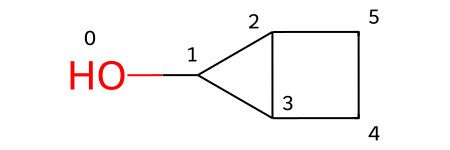

In [17]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices = True
mol = Chem.MolFromSmiles('OC1C2C1CC2')
mol

In [18]:
for atom in mol.GetAtoms():
  idx = atom.GetIdx()
  ring = atom.IsInRing()
  r3 = atom.IsInRingSize(3)
  r4 = atom.IsInRingSize(4)
  r6 = atom.IsInRingSize(6)
  print(idx, ring, r3, r4, r6)

0 False False False False
1 True True False False
2 True True True False
3 True True True False
4 True False True False
5 True False True False


2
[1, 2, 3]
[4, 5, 2, 3]


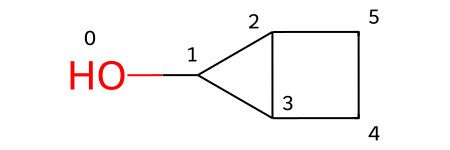

In [19]:
mol = Chem.MolFromSmiles("OC1C2C1CC2")
smallestSetOfSmallestRings = Chem.GetSymmSSSR(mol)
n_sssr = len(smallestSetOfSmallestRings)
print(n_sssr)
for i in range(n_sssr): print(list(smallestSetOfSmallestRings[i]))
mol

2
[1, 2, 3, 4, 5, 0]
[6, 7, 8, 9, 0, 5]


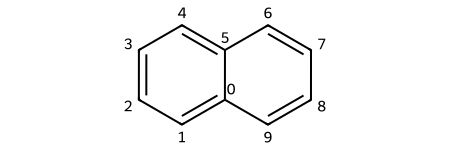

In [20]:
mol = Chem.MolFromSmiles("c12ccccc1cccc2")
smallestSetOfSmallestRings = Chem.GetSymmSSSR(mol)
n_sssr = len(smallestSetOfSmallestRings)
print(n_sssr)
for i in range(n_sssr): print(list(smallestSetOfSmallestRings[i]))
mol

6
[0, 3, 2, 1]
[0, 7, 6, 1]
[0, 7, 4, 3]
[1, 6, 5, 2]
[3, 4, 5, 2]
[7, 4, 5, 6]


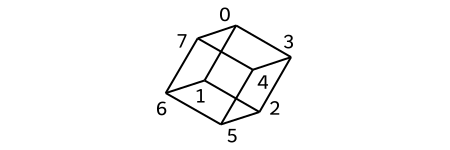

In [21]:
mol = Chem.MolFromSmiles("[C@H]12[C@@H]3[C@@H]4[C@H]1[C@H]5[C@@H]4[C@H]3[C@@H]25")
smallestSetOfSmallestRings = Chem.GetSymmSSSR(mol)
n_sssr = len(smallestSetOfSmallestRings)
print(n_sssr)
for i in range(n_sssr): print(list(smallestSetOfSmallestRings[i]))
mol

## 3. Reading and writing molecules

### 3.1 Single molecules

The pattern below - try to parse, then test for `None` - is worth memorising. The second cell shows
what RDKit does with an aromatic ring it cannot make sense of: the message "Can't kekulize mol"
means that no alternating pattern of single and double bonds can be assigned.

In [22]:
mol = Chem.MolFromSmiles("c1ccccc1")
mol is None

False

In [23]:
mol = Chem.MolFromSmiles("c1cCc1")
mol is None

[09:35:56] Can't kekulize mol.  Unkekulized atoms: 0 1 3


True

In [24]:
smiles = ['c1ccccc1', 'c1cCc1']
mols = []
for s in smiles:
  mol = Chem.MolFromSmiles(s)
  if mol is None:
    continue
  else:
    mols.append(mol)
print(len(mols))

1


[09:36:02] Can't kekulize mol.  Unkekulized atoms: 0 1 3


### 3.2 InChI strings

A SMILES string is **not** unique: the same molecule can be written in many valid ways, and only
RDKit's *canonical* SMILES is reproducible, and then only within the same version of the toolkit.
The **InChI** was designed to fix exactly that: it is a layered, strictly defined identifier, so
two laboratories that enter the same structure independently arrive at the same InChI. That is why
databases such as ChEMBL and the PDB use InChI keys to recognise identical compounds - and why, in
notebook 5, the InChI key is what lets us check that a literature compound and a PDB ligand really
are the same molecule.

**Question 5.** Write benzene in three different but valid SMILES forms and check with
`Chem.MolToSmiles()` that RDKit reduces all three to the same canonical string. What does that tell
you about using a raw SMILES string as a database key?

In [25]:
from rdkit.Chem import inchi
mol = Chem.MolFromSmiles("C1CCNCC1")
inchistring = inchi.MolToInchi(mol)
print(inchistring)
mol = inchi.MolFromInchi(inchistring)
print(Chem.MolToSmiles(mol))

InChI=1S/C5H11N/c1-2-4-6-5-3-1/h6H,1-5H2
C1CCNCC1


### 3.3 MOL blocks

A **MOL block** is the text format you met in section 1: a counts line, one line per atom with its
coordinates, and one line per bond. `MolToMolBlock()` writes one. Look carefully at the third
column of the atom lines in the output below - every z coordinate is zero, because this molecule
has only been given a two-dimensional depiction so far.

In [26]:
mol = Chem.MolFromSmiles('C1CCC1')
print(Chem.MolToMolBlock(mol))


     RDKit          2D

  4  4  0  0  0  0  0  0  0  0999 V2000
   -0.6824   -0.1850    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.1850    0.6824    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.6824    0.1850    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.1850   -0.6824    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0
  2  3  1  0
  3  4  1  0
  4  1  1  0
M  END



### 3.4 Property data

A molecule can carry arbitrary extra data as **properties**: a name, an identifier, a measured
activity, a score. Property names that begin with an underscore have a special meaning, and
`_Name` is the title line of the MOL block. In notebook 4 the vendor catalogue number is stored in
exactly this way, and notebook 5 reads it back out again to label its hits.

In [27]:
mol.SetProp("_Name","cyclobutane")
print(Chem.MolToMolBlock(mol))

cyclobutane
     RDKit          2D

  4  4  0  0  0  0  0  0  0  0999 V2000
   -0.6824   -0.1850    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.1850    0.6824    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.6824    0.1850    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.1850   -0.6824    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0
  2  3  1  0
  3  4  1  0
  4  1  1  0
M  END



In [28]:
mol.GetProp("_Name")

'cyclobutane'

### 3.5 Working with conformations

So far our molecules have been graphs with, at most, a flat drawing. A **conformation** is a set of
real three-dimensional coordinates. `EmbedMolecule()` produces one by distance geometry: it builds
a geometry that satisfies the bond lengths, angles and ring constraints, and then cleans it up with
a force field. `EmbedMultipleConfs()` does the same thing several times and gives you an ensemble.

This matters far beyond this notebook. A flexible molecule has many accessible shapes, and a
method that depends on shape - pharmacophore matching in notebook 5, or docking - can only
recognise a molecule if the shape it needs is among the ones you generated. `AlignMolConformers()`
superimposes the conformers and reports how much they differ as an RMS value.

**Question 6.** Run the cell that makes ten conformers and look at the RMS values. They are all
roughly 1 A. Aspirin has one freely rotating ester group; what would these numbers look like for a
rigid molecule such as benzene, and what for a long flexible chain? How many conformers do you
think you would need for a molecule with ten rotatable bonds?

In [ ]:
mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
mol.SetProp("_Name", "aspirine")
print(Chem.MolToMolBlock(mol))

In [30]:
mol = Chem.AddHs(mol)
print(Chem.MolToMolBlock(mol))

aspirine
     RDKit          2D

 21 21  0  0  0  0  0  0  0  0999 V2000
   -2.6641    0.3129    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7991   -0.1887    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.8011   -1.1887    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
   -0.9321    0.3095    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
   -0.0671   -0.1921    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.0689   -1.1921    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7959   -1.6939    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.6631   -1.1957    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.6649   -0.1957    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.8001    0.3061    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.8021    1.3061    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.0629    1.8077    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    1.6691    1.8043    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
   -2.1623    1.1

In [31]:
AllChem.EmbedMolecule(mol)
print(Chem.MolToMolBlock(mol))

aspirine
     RDKit          3D

 21 21  0  0  0  0  0  0  0  0999 V2000
   -2.7942   -2.2417   -0.0445 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.9475   -1.0749    0.3038 C   0  0  0  0  0  0  0  0  0  0  0  0
   -2.1173   -0.4725    1.3695 O   0  0  0  0  0  0  0  0  0  0  0  0
   -0.9753   -0.7008   -0.6074 O   0  0  0  0  0  0  0  0  0  0  0  0
   -0.1082    0.3350   -0.4667 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4778    1.5789   -0.9415 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.3780    2.6655   -0.8185 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.6153    2.5491   -0.2256 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.9815    1.3083    0.2468 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.1359    0.2231    0.1282 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.5458   -1.0802    0.6359 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7917   -2.0601    0.5331 O   0  0  0  0  0  0  0  0  0  0  0  0
    2.7769   -1.2679    1.2435 O   0  0  0  0  0  0  0  0  0  0  0  0
   -3.0015   -2.2

In [32]:
mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
mol = Chem.AddHs(mol)
conformationIds = AllChem.EmbedMultipleConfs(mol, numConfs=10)
print(len(conformationIds))
w = Chem.SDWriter("scratch/aspirin.sdf")
for cid in conformationIds: w.write(mol, confId = cid)
w.close()

10


In [33]:
mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
mol = Chem.AddHs(mol)
conformationIds = AllChem.EmbedMultipleConfs(mol, numConfs=10)
rmslist = []
AllChem.AlignMolConformers(mol, RMSlist = rmslist)
for rms in rmslist: print(rms)
w = Chem.SDWriter("scratch/aspirin.sdf")
for cid in conformationIds: w.write(mol, confId = cid)
w.close()

1.022083343586314
1.2882988354458471
1.158607806147065
1.194515920670335
0.809819242966771
0.9407567986313173
0.9558594549414686
1.0026702693306295
1.3177160124616887


## 4. Substructure searching: SMARTS

**SMARTS** is to substructures what SMILES is to molecules: a line of text describing a *pattern*
rather than a compound. `ccO` means "an aromatic carbon, bonded to an aromatic carbon, bonded to an
oxygen". `HasSubstructMatch()` answers yes or no, `GetSubstructMatch()` returns the atom indices of
one match and `GetSubstructMatches()` returns all of them.

SMARTS has its own vocabulary on top of SMILES: `[OH]` is an oxygen carrying a hydrogen, and
`[$(...)]` lets you require that an atom sits in a larger environment, as in the last cell of this
section. This is the mechanism behind the substructure filters used throughout medicinal chemistry -
and, in notebook 5, behind the perception of pharmacophore features.

**Question 7.** The last cell tests three bromophenols against one pattern and only two of them
match. Work out from the SMARTS why the middle compound is rejected. Then change the pattern so
that all three match.

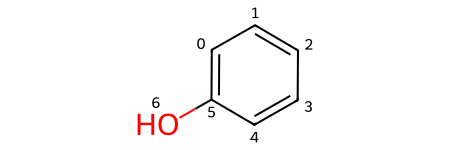

In [34]:
m = Chem.MolFromSmiles('c1ccccc1O')
m

In [35]:
smartsMol = Chem.MolFromSmarts('ccO')
m.HasSubstructMatch(smartsMol)

True

In [36]:
m.GetSubstructMatch(smartsMol)

(0, 5, 6)

In [37]:
m.GetSubstructMatches(smartsMol)

((0, 5, 6), (4, 5, 6))

In [38]:
bromophenols = ["Oc1ccccc1Br", "Oc1cccc(Br)c1", "Oc1ccc(Br)cc1"]
mols = []
for bp in bromophenols: mols.append(Chem.MolFromSmiles(bp))

In [39]:
p = Chem.MolFromSmarts("Br[$(c1c([OH])cccc1),$(c1ccc([OH])cc1)]")
for mol in mols:
  if mol.HasSubstructMatch(p):
    print(Chem.MolToSmiles(mol), "True")
  else:
    print(Chem.MolToSmiles(mol), "False")

Oc1ccccc1Br True
Oc1cccc(Br)c1 False
Oc1ccc(Br)cc1 True


## 5. Working with many molecules at once

### 5.1 Reading multiple chemical structures

Everything so far was a single molecule. Real work starts at the other end of the scale: files with
thousands or millions of structures. `Chem.SDMolSupplier()` reads an SD file and hands you the
molecules one at a time, and the same `None` check as before applies, because a large file almost
always contains a few records that cannot be parsed.

The RDKit also provides the ability to read molecules from common molecular structure formats. In the code below we use the RDKit's **Chem.SDMolSupplier()** function to read molecules from an [SD file](https://en.wikipedia.org/wiki/Chemical_table_file). First, we'll download the file from GitHub:

In [ ]:
url = "https://raw.githubusercontent.com/UAMCAntwerpen/2040FBDBIC/master/assets/databases/notebook-2/example-compounds.sdf"
r = requests.get(url)
bytes_written = open('scratch/example_compounds.sdf', 'w').write(r.text)

Now we''ll read the file:

In [ ]:
mols = [x for x in Chem.SDMolSupplier("scratch/example_compounds.sdf")]

The code above reads the molecules into a list. When we display this, we see a list of molecule objects. Below we'll take a look at a couple of ways to display multiple chemical structures in a grid:

In [ ]:
mols

### 5.2 Displaying multiple chemical structures in a grid

Looking at your molecules is not a luxury. A grid of structures is the fastest way to notice that
your supposedly diverse selection is twenty copies of the same scaffold, or that a filter has
quietly kept only the carboxylic acids. You will use these grids in every remaining notebook.

The RDKit's built-in **MolsToGridImage()** method provides a convenient way of displaying a grid of structures:

In [40]:
from rdkit.Chem.Draw import MolsToGridImage, rdMolDraw2D, MolsMatrixToGridImage
import copy

In [ ]:
# Show the first twelve molecules of the SD file, with their index as a legend
MolsToGridImage(mols[:12],
                legends=[str(i) for i in range(12)],
                molsPerRow=4,
                subImgSize=(250, 200))

### 5.3 A grid laid out as a matrix

`MolsMatrixToGridImage()` is the variant to use when the *position* in the grid carries meaning -
one row per reaction, one column per starting material, as in the example below. Each row may have
a different length.

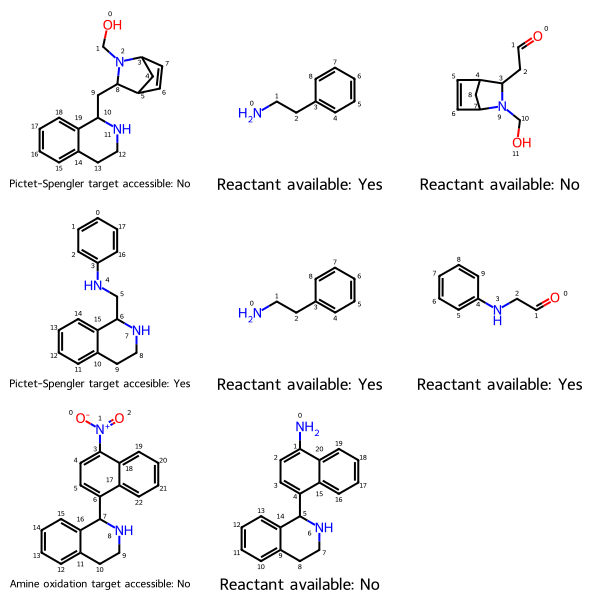

In [41]:
# MolsMatrixToGridImage usage
synSmilesMatrix = [['OCN1C2CC(C=C2)C1CC1NCCc2ccccc12', 'NCCc1ccccc1', 'O=CCC1C2C=CC(C2)N1CO'], ['c1ccc(NCC2NCCc3ccccc32)cc1', 'NCCc1ccccc1', 'O=CCNc1ccccc1'], ['[O-][N+](=O)C1=CC=C(C2NCCc3ccccc23)C2=C1C=CC=C2', 'Nc1ccc(C2NCCc3ccccc32)c2ccccc12']]
synMolsMatrix = [[Chem.MolFromSmiles(smile) for smile in row] for row in synSmilesMatrix]
synLegendsMatrix = [['Pictet-Spengler target accessible: No', 'Reactant available: Yes', 'Reactant available: No'], ['Pictet-Spengler target accesible: Yes', 'Reactant available: Yes', 'Reactant available: Yes'], ['Amine oxidation target accessible: No', 'Reactant available: No']]
MolsMatrixToGridImage(molsMatrix=synMolsMatrix, legendsMatrix=synLegendsMatrix)

## 6. Exercises

1. Take the SMILES of imatinib from section 2 and report its molecular weight, its cLogP and the
   number of rings it contains. Which RDKit module did you need for each of the three?
2. Write a loop that reads the SD file of section 5, keeps only the molecules with a molecular
   weight below 300, and shows them in a grid. How many are left?
3. Write a SMARTS pattern for a secondary amide (a nitrogen carrying one hydrogen, bonded to a
   carbonyl carbon) and count how many molecules in the SD file contain one.
4. Generate 20 conformers of imatinib, align them, and print the largest RMS value you find.
   Imatinib has seven rotatable bonds - does the spread you find match that?

## Finished?

You can now move a molecule into and out of the computer in every representation this course needs:
a string when you want speed, a graph when you want atoms and bonds, coordinates when you want
shape. You have also met the two ideas that the rest of the course leans on most heavily - that a
molecule has *many* three-dimensional shapes, and that a substructure pattern is itself a kind of
query.

Then you can move to the third notebook, where these representations are turned into numbers that
a machine-learning model can digest:

- [Notebook 3: Building machine learning models](Notebook-3-Building-ML-models.ipynb)

However, if you feel that your `Python` skills are still somewhat behind, then it might be wise to
repeat the [intro session again](Notebook-0-Introduction.ipynb).